<a href="https://colab.research.google.com/github/sonjoy1s/DeepLearningKaggleProject/blob/main/Fashion_MNIST_eita_diye_all_project_korte_parbo_pray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [198]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [199]:
torch.manual_seed(42)

In [200]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [201]:
df = pd.read_csv('/content/fashion-mnist_train.csv.zip', compression='zip')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Image graph img dekhar jonno

In [202]:
#fruits = ['Apple','banana','Mango']
#for index, fruit in enumerate(fruits):
#  print(index,fruit)

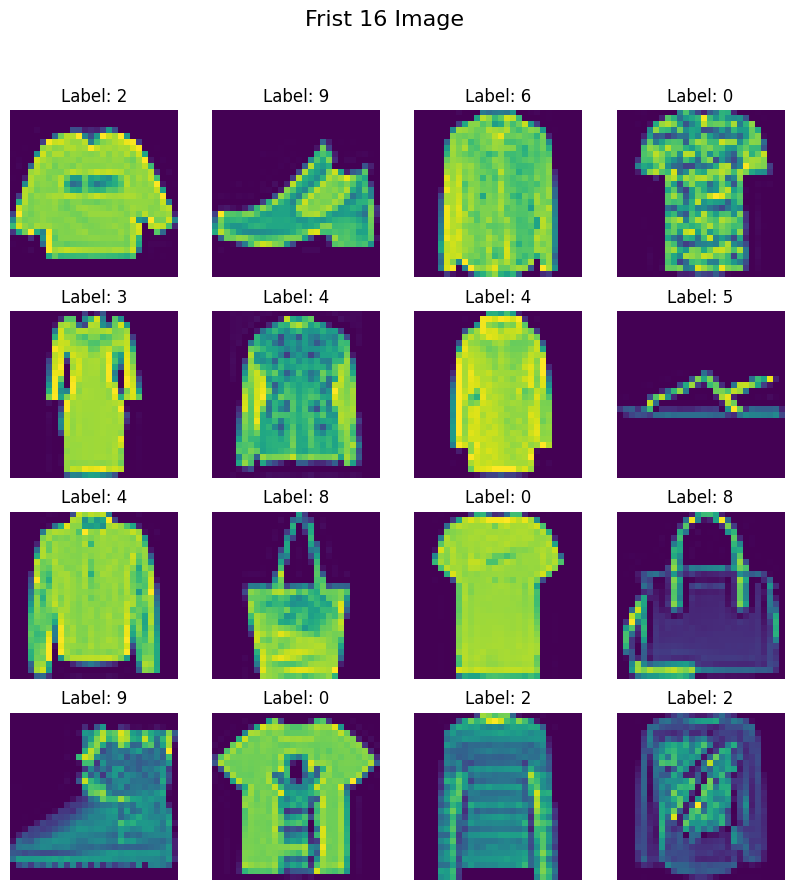

In [203]:
fig, axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle("Frist 16 Image",fontsize=16)

for i , ax in enumerate(axes.flat):     #flat korle ekta ekta image jabe graph e
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis("Off")
  ax.set_title(f"Label: {df.iloc[i,0]}")

In [204]:
len(df.columns)

785

In [205]:
len(df['label'].unique())

10

In [206]:
len(df.iloc[:,1:])# columns selection prothom ta sob row nibe 2nd ta 1 ta col badh diye sob col nibe

60000

In [207]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values #sob row nibe ar 0 mane 1 ta target col nibe

In [208]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [209]:
# Scaling features
X_train = X_train / 255.0
X_test = X_test / 255.0

CustomDataset

In [210]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    #convet to pytroch tensor
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)


  def __getitem__(self,index):
    return self.features[index],self.labels[index]


In [211]:
#train dataset ar test dataset make :

train_dataset = CustomDataset(X_train,y_train)

test_dataset = CustomDataset(X_test,y_test)

In [212]:
len(train_dataset),len(test_dataset)

(48000, 12000)

Loader dataset

In [213]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)

# Define NN Module

In [214]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10),

    )


  def forward(self,X):
    return self.model(X)

# Instatial Model

In [215]:
epochs = 10
learning_rate = 0.1

In [216]:
model = MyNN(X_train.shape[1])
model = model.to(device) # eita cpu to Gpu er kaj

In [217]:
#loss function
criterion = nn.CrossEntropyLoss()

model.parameters()

<generator object Module.parameters at 0x7c240beb59a0>

In [218]:
#optimizer
optimizer = optim.SGD(model.parameters(),lr=learning_rate)


In [219]:
len(train_loader)

1500

# Train Loop

In [220]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features,batch_labels in train_loader:
    #move to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    #forward pass
    output = model(batch_features)

    #calculate loss
    loss = criterion(output,batch_labels)

    #back pass
    optimizer.zero_grad()  # 1st e optimizer 0 kore nite hoy backward er jonno
    loss.backward()

    #update
    optimizer.step()

    # print(loss.item())
    total_epoch_loss = total_epoch_loss + loss.item()


avg_loss = total_epoch_loss / len(train_loader)

print(avg_loss)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.27479909772674244


# Evulation Model

In [221]:
model.eval()
total =0
correct = 0
with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    # move to gpu
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)
    output = model(batch_features)
    print(f"Output shape: {output}")
    _,predicted = torch.max(output,1)
    print(f"Predicted shape: {predicted}")
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

print(f"Total: {total}")
print(f"Correct: {correct}")
print(f"Accuracy: {correct/total}")


Streaming output truncated to the last 5000 lines.
         -4.8590e+00,  3.8721e+00, -5.5037e+00, -2.6418e+00, -2.7985e+00],
        [ 5.9167e+00,  3.3457e-01, -1.0715e+00,  1.5757e+01, -2.5309e+00,
         -5.7889e+00,  4.2430e+00, -8.9691e+00, -1.8620e+00, -6.4058e+00],
        [-4.4426e+00, -1.1929e+00, -4.7219e+00, -3.4227e+00, -2.8352e+00,
          4.3296e+00, -6.2607e+00,  1.3509e+01,  1.1211e+00,  3.9362e+00],
        [-2.0157e+00, -1.8301e+00, -1.6410e+00, -2.5270e+00, -3.0315e+00,
          1.1629e+01, -3.7429e+00,  4.4527e+00, -2.3331e-01, -1.7157e+00],
        [ 3.4440e+00,  1.4875e+00,  3.8441e-01,  1.1966e+01, -6.8815e-01,
         -6.5134e+00,  2.9607e+00, -7.5128e+00, -1.0954e+00, -5.2771e+00],
        [ 6.5155e+00,  3.0460e-01, -1.8476e-02,  7.3727e+00, -1.5017e+00,
         -3.4766e+00,  3.2262e+00, -6.6536e+00, -2.5472e-01, -6.5770e+00],
        [-1.7370e+00, -5.6587e-01,  2.1236e+00,  8.3938e+00,  6.0773e+00,
         -5.9064e+00,  1.9976e+00, -4.6945e+00, -2.6256